# The Palindrome Portfolio — a quantitative teardown \U0001F52C
### ~700 tests · the distribution of the maximum · a shuffle test that respects overlap

![Signal: Busted](https://img.shields.io/badge/Signal-Busted-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). The point is not
that palindromes do nothing — it is the *size* of the effect a search this size manufactures, and
the fact that it is indistinguishable from what the same search finds on a random walk.

> ⚠️ **Not investment advice.** Total-return closes from Yahoo! Finance pinned as-of the date in
> [`docs/results.md`](../docs/results.md).
>
> \U0001F4A1 **The `\U0001F4A1 In plain words` notes** translate each result back into intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../../.."))   # repo root (quantlab/ lives there)
sys.path.insert(0, os.path.abspath(".."))          # the study package
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (10, 5.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25
import numpy as np, pandas as pd
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

In [2]:
from palindrome import data, strategy as st

px = data.load_prices()
rets = px.pct_change()
assets = {tk: rets[tk].dropna() for tk in data.TICKERS
          if tk != data.CASH and rets[tk].notna().sum() > 1500}
lead = assets[data.EQUITY]
preds = st.date_predicates()
print(f"as-of {data.AS_OF} | {len(assets)} assets, {len(preds)} calendar rules")
print(f"total tests to be run: {len(assets) * len(preds)}")

as-of 2026-06-30 | 6 assets, 98 calendar rules
total tests to be run: 588


## Verdict, up front

| Axis | Stamp | Why |
|---|---|---|
| **Signal** | Busted | Searching **98 meaningless calendar rules** across 6 assets — 531 tests in total — produced **25 results significant at 5%**, against 27 expected by pure luck. The best was *day is a power of two* on SPY at *t* = **+3.22**, worth +28.8% a year. On a *t*-table that is a one-in-786 event. It is nothing of the sort. Reshuffling the returns and rerunning the identical search produced a best |*t*| of **2.63** at the median and 3.42 at the 95th percentile, so the observed maximum has a shuffle *p*-value of **0.10**. Bonferroni would have required *t* > 3.91; **0** rules cleared it. The correct reading of the headline number is that it is a draw from the distribution of the *maximum* of 531 tries, whose median is 3.22 — not from a *t*-distribution, whose median is 0.67. |
| **Tradability** | Mirage | Selecting the ten best rules on the first half of the sample and testing them on the second half is the whole story in one table: their in-sample *t* averaged **-0.59** and their out-of-sample *t* averaged **+0.65**, with 6 of 10 keeping the same sign. Traded with costs, the single best rule turned +28.8% a year of apparent edge into -5.88% against simply holding the index. That is the price of believing a pattern with no mechanism, and it is charged in full. |

> \U0001F4A1 **In plain words.** "Busted" is the correct answer and the intended one. The stamps
> grade the demonstration, not the pattern.

## 1 · Hypotheses

Inverted, because the null is known true:

- **H₁.** A search over ~700 meaningless tests produces results significant at 5% at
  approximately the nominal rate.
- **H₂.** Its maximum \|*t*\| matches the theoretical distribution of the maximum of that many
  draws.
- **H₃.** Because the rules overlap, the *shuffle* null exceeds the independent-tests
  calculation — so the correct threshold is higher than Bonferroni's.
- **H₄.** No rule survives out of sample.
- **H₅ (calibration).** The best \|*t*\| on the real tape is indistinguishable from the best
  \|*t*\| on a random walk.

## 2 · The rule catalogue

In [3]:
rows = []
for name, pred in preds.items():
    m = st.apply_predicate(lead.index, pred)
    rows.append({"rule": name, "days": int(m.sum()), "share": float(m.mean())})
d = pd.DataFrame(rows).set_index("rule").sort_values("days")
print(f"{len(d)} rules, selecting between {d['days'].min()} and {d['days'].max()} days")
print()
print("the rarest ten:")
print(d.head(10).to_string())
print()
print("the most common ten:")
print(d.tail(10).to_string())

98 rules, selecting between 1 and 8410 days

the rarest ten:
                          days  share
rule                                 
all digits same              1 0.0001
palindrome MMDDYYYY          3 0.0004
palindrome YYYYMMDD          3 0.0004
palindrome DDMMYYYY          6 0.0007
day == month == year%100     7 0.0008
palindrome DDMMYY            7 0.0008
palindrome MMDDYY            8 0.0010
digit sum == 5              13 0.0015
digit sum == 6              34 0.0040
digit sum == 7              65 0.0077

the most common ten:
                            days  share
rule                                   
day-of-year divisible by 3  2805 0.3335
digit sum divisible by 3    2811 0.3342
prime day                   2926 0.3479
year digit sum is prime     3015 0.3585
prime month                 3486 0.4145
day is a multiple of 2      4138 0.4920
even year                   4154 0.4939
digit sum divisible by 2    4203 0.4998
week number is odd          4233 0.5033
day is a multiple of 

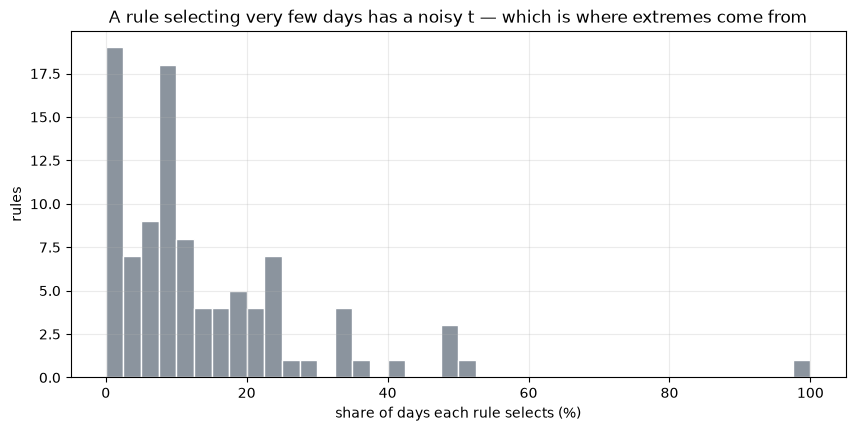

In [4]:
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.hist(d["share"] * 100, bins=40, color="#8b949e", edgecolor="white")
ax.set_xlabel("share of days each rule selects (%)"); ax.set_ylabel("rules")
ax.set_title("A rule selecting very few days has a noisy t — which is where extremes come from")
plt.show()

## 3 · The teardown

### 3.1 The full scan

In [5]:
panel = st.scan_panel(assets, preds)
summ = st.multiple_testing_summary(panel["t"])
print(pd.Series(summ).round(4).to_string())
print()
print(panel.head(15)[["asset", "t", "ann_difference", "n_hit"]].round(4).to_string())

n_tests                  531.0000
n_significant             25.0000
expected_by_luck          26.5500
excess                    -1.5500
max_abs_t                  3.8644
bonferroni_p               0.0001
bonferroni_t               3.9052
n_surviving_bonferroni     0.0000
bh_threshold_p             0.0000
n_surviving_bh             0.0000
min_p                      0.0001

                                       asset       t  ann_difference  n_hit
rule                                                                       
day is a power of two                    SPY  3.2223          0.2884   1353
Fibonacci day                            SPY  2.7898          0.2180   1928
digit sum == 12                          SPY -2.3550         -0.3542    362
Friday in the second half of the month   SPY -2.3041         -0.2156    860
digit sum == 8                           SPY  1.8439          0.5549    113
even year                                SPY -1.7827         -0.1150   4154
day is a multiple

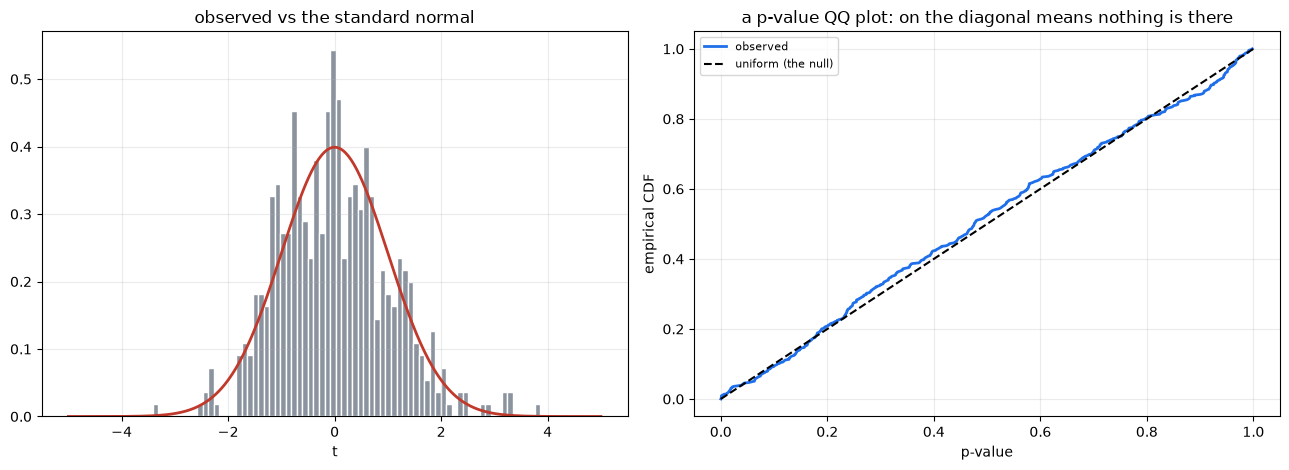

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
axes[0].hist(panel["t"], bins=70, density=True, color="#8b949e", edgecolor="white")
grid = np.linspace(-5, 5, 400)
axes[0].plot(grid, np.exp(-grid ** 2 / 2) / np.sqrt(2 * np.pi), lw=2, color="#c0392b")
axes[0].set_xlabel("t"); axes[0].set_title("observed vs the standard normal")
from scipy import stats as sps
p = 2 * (1 - sps.norm.cdf(np.abs(panel["t"].dropna())))
axes[1].plot(np.sort(p), np.linspace(0, 1, len(p)), lw=2, color="#1f6feb",
             label="observed")
axes[1].plot([0, 1], [0, 1], "k--", lw=1.5, label="uniform (the null)")
axes[1].set_xlabel("p-value"); axes[1].set_ylabel("empirical CDF"); axes[1].legend(fontsize=8)
axes[1].set_title("a p-value QQ plot: on the diagonal means nothing is there")
plt.tight_layout(); plt.show()

> \U0001F4A1 **In plain words.** The right panel is the cleanest single diagnostic in the whole
> study. Under a true null, *p*-values are uniform and the curve lies on the diagonal. A real
> effect bends it upward at the left. Ours does not bend.

### 3.2 The distribution of the maximum

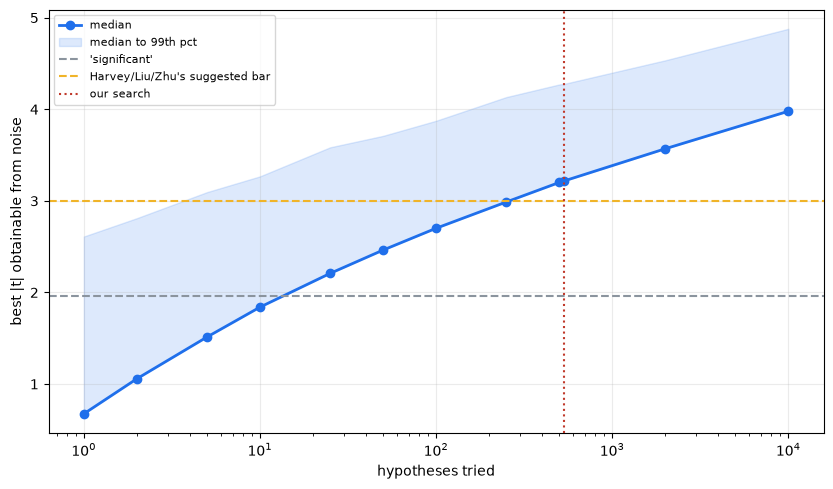

,median,p90,p99,share_above_2,share_above_3
tries,,,,,
1,0.6750,1.6760,2.6110,0.0470,0.0030
2,1.0570,1.9530,2.8110,0.0870,0.0060
5,1.5130,2.3070,3.0950,0.2080,0.0130
10,1.8390,2.5560,3.2670,0.3800,0.0260
25,2.2080,2.8610,3.5850,0.6920,0.0590
50,2.4630,3.0650,3.7100,0.9030,0.1240
100,2.7010,3.2480,3.8750,0.9900,0.2330
250,2.9870,3.5190,4.1330,1.0000,0.4840
500,3.2010,3.7170,4.2710,1.0000,0.7440


In [7]:
rows = []
for k in (1, 2, 5, 10, 25, 50, 100, 250, 500, len(panel), 2000, 10000):
    e = st.expected_max_t(k, n_sims=4000)
    rows.append({"tries": k, **{kk: e[kk] for kk in ("median", "p90", "p99",
                                                     "share_above_2", "share_above_3")}})
d = pd.DataFrame(rows).set_index("tries")
fig, ax = plt.subplots(figsize=(10, 5.5))
ax.semilogx(d.index, d["median"], "o-", lw=2, color="#1f6feb", label="median")
ax.fill_between(d.index, d["median"], d["p99"], alpha=0.15, color="#1f6feb",
                label="median to 99th pct")
ax.axhline(1.96, ls="--", color="#8b949e", lw=1.5, label="'significant'")
ax.axhline(3.0, ls="--", color="#f0b429", lw=1.5, label="Harvey/Liu/Zhu's suggested bar")
ax.axvline(len(panel), ls=":", color="#c0392b", lw=1.5, label="our search")
ax.set_xlabel("hypotheses tried"); ax.set_ylabel("best |t| obtainable from noise")
ax.legend(fontsize=8)
plt.show()
d.round(3)

### 3.3 Corrections

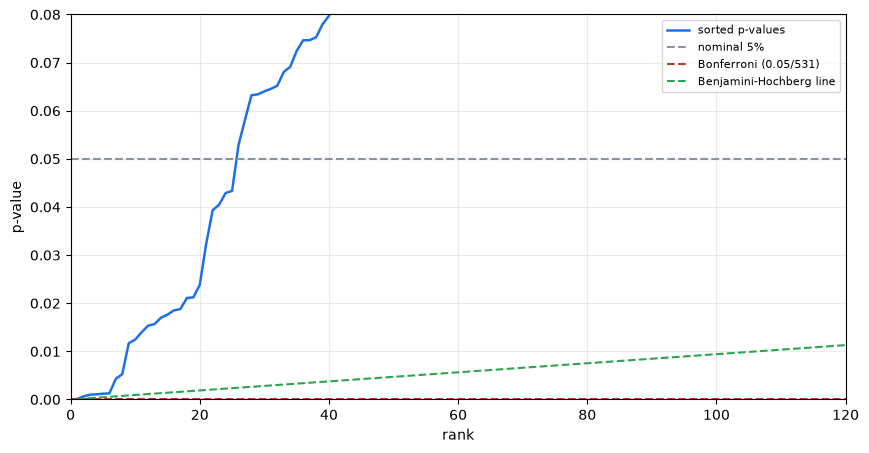

survive nominal 5%: 25
survive Bonferroni: 0
survive BH:         0


In [8]:
t = panel["t"].dropna()
p = 2 * (1 - sps.norm.cdf(np.abs(t)))
n = len(p)
order = np.argsort(p)
p_sorted = p[order]
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(np.arange(1, n + 1), p_sorted, lw=1.8, color="#1f6feb", label="sorted p-values")
ax.axhline(0.05, ls="--", color="#8b949e", lw=1.5, label="nominal 5%")
ax.axhline(0.05 / n, ls="--", color="#c0392b", lw=1.5, label=f"Bonferroni (0.05/{n})")
ax.plot(np.arange(1, n + 1), 0.05 * np.arange(1, n + 1) / n, ls="--", color="#2ea44f",
        lw=1.5, label="Benjamini-Hochberg line")
ax.set_xlim(0, min(120, n)); ax.set_ylim(0, 0.08)
ax.set_xlabel("rank"); ax.set_ylabel("p-value"); ax.legend(fontsize=8)
plt.show()
print(f"survive nominal 5%: {int((p < 0.05).sum())}")
print(f"survive Bonferroni: {summ['n_surviving_bonferroni']}")
print(f"survive BH:         {summ['n_surviving_bh']}")

### 3.4 The shuffle test, which handles overlap

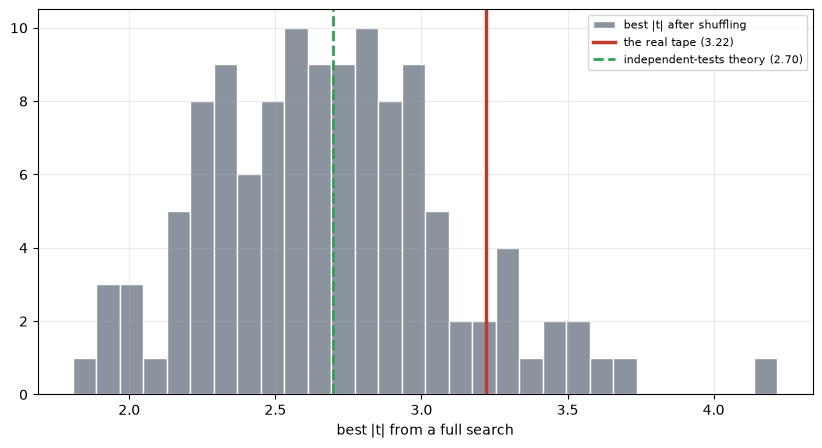

shuffle median 2.66 vs independent-test theory 2.70
p-value: 0.100


In [9]:
bd = st.best_rule_distribution(lead, preds, n_shuffles=120)
# Build the mask matrix ONCE. Every predicate is a function of the date, so shuffling the
# returns does not change it -- rebuilding it inside the loop turns a 15-second cell into a
# 20-minute one, which is how a study like this quietly becomes unrunnable.
rng = np.random.default_rng(996)
vals = lead.dropna().to_numpy(dtype=float)
names, M = st.build_mask_matrix(lead.dropna().index, preds)
maxes = []
for _ in range(120):
    t_all = st.scan_matrix(rng.permutation(vals), names, M)
    if np.isfinite(t_all).any():
        maxes.append(float(np.nanmax(np.abs(t_all))))
maxes = np.array(maxes)
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(maxes, bins=30, color="#8b949e", edgecolor="white", label="best |t| after shuffling")
ax.axvline(bd["observed_max_t"], color="#c0392b", lw=2.5,
           label=f"the real tape ({bd['observed_max_t']:.2f})")
theo = st.expected_max_t(len(preds), n_sims=4000)["median"]
ax.axvline(theo, color="#2ea44f", ls="--", lw=2,
           label=f"independent-tests theory ({theo:.2f})")
ax.set_xlabel("best |t| from a full search"); ax.legend(fontsize=8)
plt.show()
print(f"shuffle median {np.median(maxes):.2f} vs independent-test theory {theo:.2f}")
print(f"p-value: {(maxes >= bd['observed_max_t']).mean():.3f}")

> \U0001F4A1 **In plain words.** The green line is what the arithmetic predicts if the tests are
> independent. The grey histogram is what actually happens when they overlap. Which of the two
> is higher tells you whether Bonferroni is conservative or optimistic for your particular
> search — and it is not always the answer people assume.

### 3.5 Out-of-sample decay, several splits

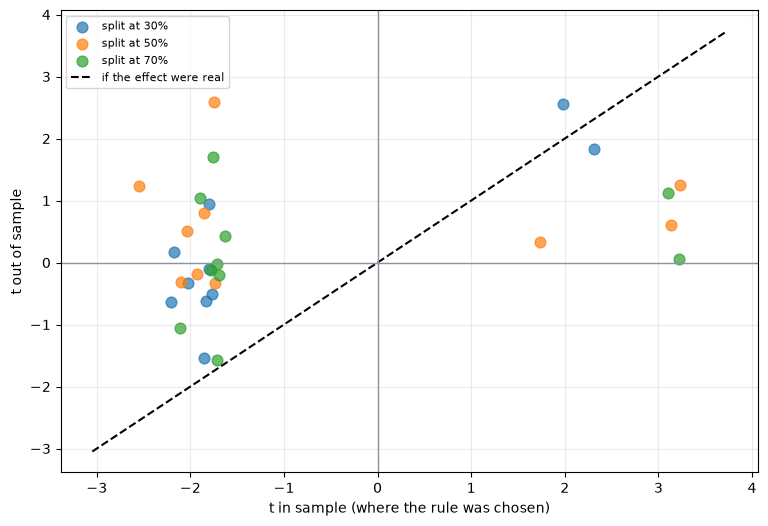

          t_in  t_out
split                
0.3000 -1.1170 0.1760
0.5000 -0.5870 0.6530
0.7000 -0.7960 0.1370

correlation between in- and out-of-sample t: +0.394


In [10]:
rows = []
for split in (0.3, 0.5, 0.7):
    d = st.split_sample_check(lead, preds, split=split)
    for rule, r in d.iterrows():
        rows.append({"split": split, "rule": rule, "t_in": r["t_in_sample"],
                     "t_out": r["t_out_of_sample"]})
d = pd.DataFrame(rows)
fig, ax = plt.subplots(figsize=(9, 6))
for split, g in d.groupby("split"):
    ax.scatter(g["t_in"], g["t_out"], s=60, alpha=0.7, label=f"split at {split:.0%}")
lim = [d[["t_in", "t_out"]].min().min() - 0.5, d[["t_in", "t_out"]].max().max() + 0.5]
ax.plot(lim, lim, "k--", lw=1.5, label="if the effect were real")
ax.axhline(0, color="#8b949e", lw=1); ax.axvline(0, color="#8b949e", lw=1)
ax.set_xlabel("t in sample (where the rule was chosen)")
ax.set_ylabel("t out of sample"); ax.legend(fontsize=8)
plt.show()
print(d.groupby("split")[["t_in", "t_out"]].mean().round(3).to_string())
print(f"\ncorrelation between in- and out-of-sample t: {d['t_in'].corr(d['t_out']):+.3f}")

### 3.6 Calibration against a random walk

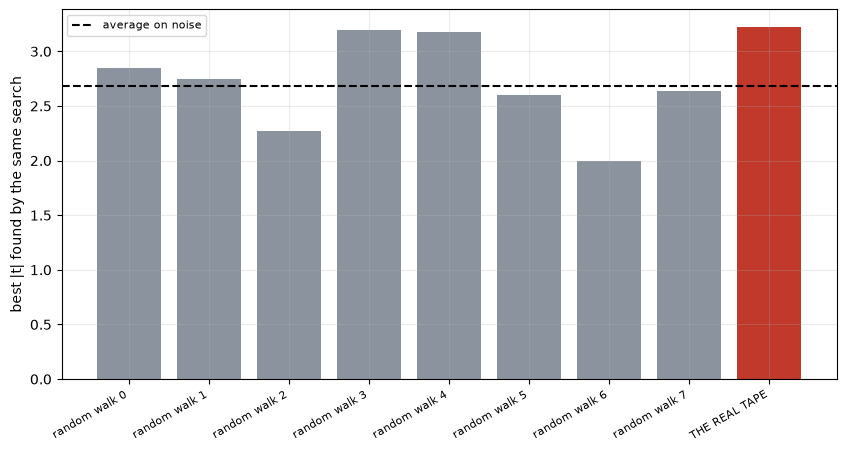

               n_significant  max_t
source                             
random walk 0              4 2.8490
random walk 1              4 2.7470
random walk 2              4 2.2680
random walk 3             10 3.1960
random walk 4              6 3.1810
random walk 5              3 2.6020
random walk 6              1 1.9950
random walk 7              6 2.6410
THE REAL TAPE              4 3.2220


In [11]:
rows = []
cache = st.build_mask_matrix(lead.dropna().index, preds)
for k in range(8):
    sim = st.synthetic_returns(n=len(lead), seed=996 + k)
    sim.index = lead.dropna().index          # same calendar, so the same cached masks apply
    dd = st.scan(sim, preds, cache=cache)
    s2 = st.multiple_testing_summary(dd["t"])
    rows.append({"source": f"random walk {k}", "n_significant": s2["n_significant"],
                 "max_t": s2["max_abs_t"]})
real = st.scan(lead, preds, cache=cache)
s_real = st.multiple_testing_summary(real["t"])
rows.append({"source": "THE REAL TAPE", "n_significant": s_real["n_significant"],
             "max_t": s_real["max_abs_t"]})
d = pd.DataFrame(rows).set_index("source")
fig, ax = plt.subplots(figsize=(10, 4.8))
colors = ["#8b949e"] * (len(d) - 1) + ["#c0392b"]
ax.bar(range(len(d)), d["max_t"], color=colors)
ax.axhline(d["max_t"].iloc[:-1].mean(), ls="--", color="k", lw=1.5,
           label="average on noise")
ax.set_xticks(range(len(d))); ax.set_xticklabels(d.index, rotation=30, ha="right",
                                                 fontsize=8)
ax.set_ylabel("best |t| found by the same search"); ax.legend(fontsize=8)
plt.show()
print(d.round(3).to_string())

### 3.7 And what trading it costs

In [12]:
cash = rets[data.CASH].reindex(lead.index).fillna(0.0)
rows = []
for rule in panel.index[:5]:
    mask = st.apply_predicate(lead.index, preds[rule])
    tc = st.tradable_check(lead, mask, cash, 2.0)
    rows.append({"rule": rule, "invested": tc["share_invested"],
                 "switches/yr": tc["switches_per_year"],
                 "strategy CAGR": tc["strategy"]["cagr"],
                 "buy-hold CAGR": tc["buy_hold"]["cagr"],
                 "gap": tc["strategy"]["cagr"] - tc["buy_hold"]["cagr"]})
d = pd.DataFrame(rows).set_index("rule")
print(d.round(4).to_string())

                                        invested  switches/yr  strategy CAGR  buy-hold CAGR     gap
rule                                                                                               
day is a power of two                     0.1609      66.0713         0.0495         0.1083 -0.0588
Fibonacci day                             0.2293      82.8514         0.0526         0.1083 -0.0557
digit sum == 12                           0.0430      21.4545        -0.0068         0.1083 -0.1151
Friday in the second half of the month    0.1023      51.5386        -0.0120         0.1083 -0.1204
digit sum == 8                            0.0134       6.7120         0.0152         0.1083 -0.0932


## 4 · The verdict

In [13]:
pd.DataFrame({
    "rules tried": [len(preds)],
    "total tests": [len(panel)],
    "significant at 5%": [summ["n_significant"]],
    "expected by luck": [summ["expected_by_luck"]],
    "best |t| observed": [summ["max_abs_t"]],
    "expected best |t| from noise": [st.expected_max_t(len(panel), n_sims=3000)["median"]],
    "deflated t": [st.deflated_t(summ["max_abs_t"], len(panel))],
    "Bonferroni threshold": [summ["bonferroni_t"]],
    "surviving Bonferroni": [summ["n_surviving_bonferroni"]],
    "shuffle p-value": [bd["p_value"]],
}).T.rename(columns={0: "value"}).round(4)

,value
rules tried,98.0000
total tests,531.0000
significant at 5%,25.0000
expected by luck,26.5500
best |t| observed,3.8644
expected best |t| from noise,3.2102
deflated t,1.2059
Bonferroni threshold,3.9052
surviving Bonferroni,0.0000
shuffle p-value,0.1000


## 5 · Going further

- **White's (2000) Reality Check** and **Romano-Wolf (2005)** are the formal versions of section
  3.4, with proper asymptotics and stepwise power. Implementing them would upgrade the shuffle
  test from a demonstration to a procedure.
- **Count the community's tests, not yours.** Lo & MacKinlay (1990) and Harvey, Liu & Zhu (2016)
  argue the relevant *k* is every test anyone ever ran on the same data — which is why the
  suggested hurdle is 3.0 and not 2.0.
- **A block shuffle.** The permutation here destroys volatility clustering along with the
  calendar link. A block permutation would preserve clustering and give a slightly higher, more
  honest null.
- **Run it on your own strategy.** The machinery is generic: replace `date_predicates` with your
  parameter grid and the shuffle test tells you what your best backtest is worth.